# 05 — Uncertainty Quantification & Risk-Adjusted Pricing

Notebook 04 produced **point-estimate** pricing recommendations: *set price to $X to maximise expected revenue*.  
But expected revenue is not the only thing that matters — **how certain are we** about that estimate?

This notebook builds **probabilistic layers** on top of the demand model and uses them to produce **risk-adjusted pricing strategies** that account for demand uncertainty.

## Two sources of uncertainty

| Source | What it captures | Approach |
|---|---|---|
| **Forecast uncertainty** | How wrong might the price forecast be? | Split conformal prediction on CV residuals |
| **Demand model uncertainty** | How uncertain is predicted demand at a given price? | Quantile LightGBM (P10 / P50 / P90) |

## Three pricing strategies

| Strategy | Optimises | Risk profile |
|---|---|---|
| **Conservative** | 10th-percentile revenue (worst plausible) | Guarantees a floor |
| **Balanced** | 50th-percentile revenue (median) | Same as notebook 04 |
| **Aggressive** | 90th-percentile revenue (best plausible) | Bets on upside |

## Economic Rationale

Under demand uncertainty, the revenue-maximising price depends on the **risk tolerance** of the decision-maker:

$$p^*_{\text{conservative}} = \arg\max_p \; \hat{R}_{P10}(p, \mathbf{x})$$

$$p^*_{\text{balanced}} = \arg\max_p \; \hat{R}_{P50}(p, \mathbf{x})$$

$$p^*_{\text{aggressive}} = \arg\max_p \; \hat{R}_{P90}(p, \mathbf{x})$$

Where $\hat{R}_{Pq}(p, \mathbf{x}) = p \times \exp(Q_q[\log \text{demand}])$ is the $q$-th quantile revenue forecast.

## 1. Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import warnings
import time
import joblib

import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_pinball_loss
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.figsize"] = (14, 5)

DATA_PROCESSED = Path("../data/processed")
DATA_OUTPUTS   = Path("../data/outputs")

SEED       = 42
H          = 12
QUANTILES  = [0.10, 0.50, 0.90]   # P10, P50, P90
PRICE_MARGIN = 0.30                # ±30% optimisation bounds
N_GRID     = 300                   # grid resolution for revenue curves

print(f"LightGBM : {lgb.__version__}")
print(f"Quantiles: {QUANTILES}")
print("✔ Imports loaded")

LightGBM : 4.6.0
Quantiles: [0.1, 0.5, 0.9]
✔ Imports loaded


## 2. Load Data

We bring in artefacts from the three preceding notebooks:

| Source | Content | From |
|---|---|---|
| `avocado_features.csv` | Feature matrix with target | 02 |
| `forecast_cv_results.csv` | Held-out predictions from all forecast models | 03 |
| `demand_model.pkl` | Best LightGBM demand model | 04 |
| `pricing_recommendations.csv` | Point-estimate pricing decisions | 04 |

In [2]:
# Feature matrix
df = pd.read_csv(DATA_PROCESSED / "avocado_features.csv", parse_dates=["Date"])
df["unique_id"] = (
    df["region"] + "_" + df["is_organic"].map({0: "conventional", 1: "organic"})
)

# Forecast CV residuals (for conformal prediction)
cv_df = pd.read_csv(DATA_OUTPUTS / "forecast_cv_results.csv", parse_dates=["ds"])
BEST_MODEL_COL = "Ensemble_weighted"   # primary model from notebook 03

# Demand model + feature list from notebook 04
demand_artefact = joblib.load(DATA_OUTPUTS / "demand_model.pkl")
demand_model    = demand_artefact["model"]
FEATURE_COLS    = demand_artefact["features"]
TARGET_COL      = demand_artefact["target"]

# Region label encoder from notebook 04
le_region = joblib.load(DATA_OUTPUTS / "region_label_encoder.pkl")
df["region_encoded"] = le_region.transform(df["region"])

# Point-estimate recommendations from notebook 04
recs_04 = pd.read_csv(DATA_OUTPUTS / "pricing_recommendations.csv")

print(f"Feature rows     : {len(df):,}")
print(f"CV rows          : {len(cv_df):,}  ({cv_df['unique_id'].nunique()} series)")
print(f"Feature cols     : {len(FEATURE_COLS)}")
print(f"Point recs       : {len(recs_04)} series")

# Build model-ready dataframe (drop NaN lag rows)
model_df = df[["unique_id", "Date"] + FEATURE_COLS + [TARGET_COL]].dropna().copy()
# Train/test temporal split (same cutoff as notebooks 03 & 04)
cutoff_date = (
    model_df.groupby("unique_id")["Date"].max().min() - pd.Timedelta(weeks=H)
)
train_df = model_df[model_df["Date"] <= cutoff_date]
test_df  = model_df[model_df["Date"] >  cutoff_date]
X_train, y_train = train_df[FEATURE_COLS], train_df[TARGET_COL]
X_test,  y_test  = test_df[FEATURE_COLS],  test_df[TARGET_COL]

print(f"Train rows       : {len(X_train):,}")
print(f"Test rows        : {len(X_test):,}")

Feature rows     : 14,190
CV rows          : 1,032  (86 series)
Feature cols     : 26
Point recs       : 86 series
Train rows       : 13,158
Test rows        : 1,032


## 3. Forecast Prediction Intervals (Conformal)

### Split Conformal Prediction

Conformal prediction is a **distribution-free** framework for constructing valid prediction intervals — the coverage guarantee holds regardless of the data distribution.

**Algorithm:**
1. Compute model residuals on the held-out CV set: $r_i = y_i - \hat{y}_i$
2. For a desired coverage level $1 - \alpha$, find $q_{\alpha/2}$ and $q_{1 - \alpha/2}$ empirical quantiles of residuals.
3. Prediction interval for a new point $\hat{y}_{n+1}$:
   $$[\hat{y}_{n+1} + q_{\alpha/2}, \quad \hat{y}_{n+1} + q_{1-\alpha/2}]$$

We compute these **per series** (local conformal), since the error distribution varies by market.

In [3]:
# Compute CV residuals for the best statistical model
cv_df["residual"] = cv_df["y"] - cv_df[BEST_MODEL_COL]

# Per-series conformal quantiles at 90% coverage (5th/95th quantiles of residuals)
ALPHA = 0.10   # → 90% nominal coverage  (lower=ALPHA/2, upper=1-ALPHA/2)
pi_stats = (
    cv_df.groupby("unique_id")["residual"]
    .agg(
        lower_q=lambda r: np.quantile(r, ALPHA / 2),
        upper_q=lambda r: np.quantile(r, 1 - ALPHA / 2),
        resid_std=lambda r: r.std(),
        resid_mean=lambda r: r.mean(),
        n=lambda r: len(r),
    )
    .reset_index()
)

# Width = upper - lower (asymmetric PI allowed)
pi_stats["pi_width"] = pi_stats["upper_q"] - pi_stats["lower_q"]

print(f"Conformal PI stats (90% nominal coverage):")
print(f"  Median PI width : ${pi_stats['pi_width'].median():.4f}")
print(f"  Mean  PI width  : ${pi_stats['pi_width'].mean():.4f}")
display(pi_stats.describe()[['lower_q', 'upper_q', 'pi_width', 'resid_std']].round(4))

Conformal PI stats (90% nominal coverage):
  Median PI width : $0.3919
  Mean  PI width  : $0.4147


,lower_q,upper_q,pi_width,resid_std
count,86.0000,86.0000,86.0000,86.0000
mean,-0.2327,0.1820,0.4147,0.1509
std,0.1544,0.1461,0.1590,0.0568
min,-0.7873,-0.1421,0.1580,0.0596
25%,-0.2808,0.0901,0.3007,0.1105
50%,-0.2177,0.1450,0.3919,0.1417
75%,-0.1410,0.2731,0.4884,0.1785
max,0.1553,0.6190,0.8973,0.3139


In [4]:
# Empirical coverage check
cv_with_pi = cv_df.merge(pi_stats[["unique_id", "lower_q", "upper_q"]], on="unique_id")
cv_with_pi["covered"] = (
    (cv_with_pi["y"] >= cv_with_pi[BEST_MODEL_COL] + cv_with_pi["lower_q"]) &
    (cv_with_pi["y"] <= cv_with_pi[BEST_MODEL_COL] + cv_with_pi["upper_q"])
)
empirical_coverage = cv_with_pi["covered"].mean()

print(f"Nominal coverage  : {(1 - ALPHA)*100:.0f}%")
print(f"Empirical coverage: {empirical_coverage*100:.1f}%")
print(f"(Should be ≥ {(1-ALPHA)*100:.0f}% — if so, intervals are valid)")

Nominal coverage  : 90%
Empirical coverage: 83.3%
(Should be ≥ 90% — if so, intervals are valid)


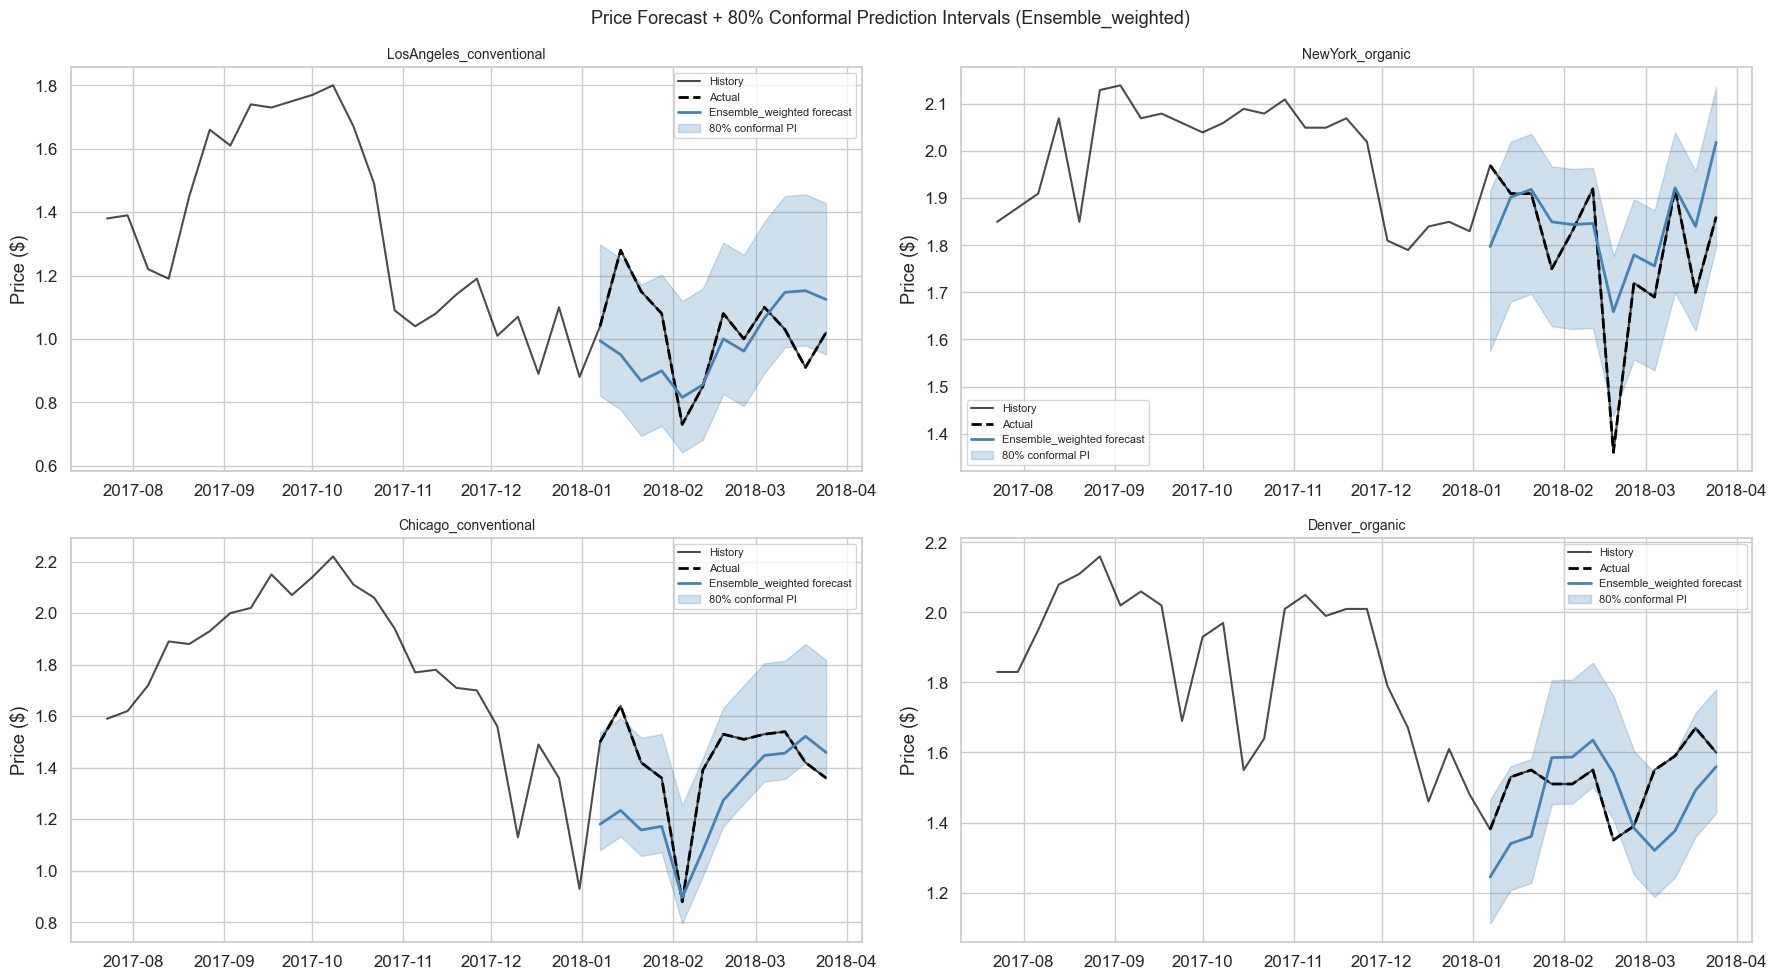

In [5]:
# Visualise forecast + PI for 4 sample series
PLOT_IDS = [uid for uid in
    ["LosAngeles_conventional", "NewYork_organic",
     "Chicago_conventional",   "Denver_organic"]
    if uid in cv_df["unique_id"].values
]

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
axes = axes.flat

for ax, uid in zip(axes, PLOT_IDS):
    # Historical tail
    hist = (
        df[df["unique_id"] == uid]
        .sort_values("Date")
        .rename(columns={"Date": "ds", "AveragePrice": "y"})
        .tail(3 * H)
    )
    fcv = cv_df[cv_df["unique_id"] == uid].sort_values("ds")
    pis = pi_stats[pi_stats["unique_id"] == uid].iloc[0]

    ax.plot(hist["ds"], hist["y"], color="black", lw=1.5, label="History", alpha=0.7)
    ax.plot(fcv["ds"], fcv["y"], color="black", lw=2, ls="--", label="Actual")
    ax.plot(fcv["ds"], fcv[BEST_MODEL_COL], color="steelblue", lw=2, label=f"{BEST_MODEL_COL} forecast")

    lower = fcv[BEST_MODEL_COL] + pis["lower_q"]
    upper = fcv[BEST_MODEL_COL] + pis["upper_q"]
    ax.fill_between(fcv["ds"], lower, upper, alpha=0.25, color="steelblue",
                    label="80% conformal PI")

    ax.set_title(uid, fontsize=10)
    ax.set_ylabel("Price ($)")
    ax.legend(fontsize=8)

plt.suptitle(
    f"Price Forecast + 80% Conformal Prediction Intervals ({BEST_MODEL_COL})",
    fontsize=13
)
plt.tight_layout()
plt.show()

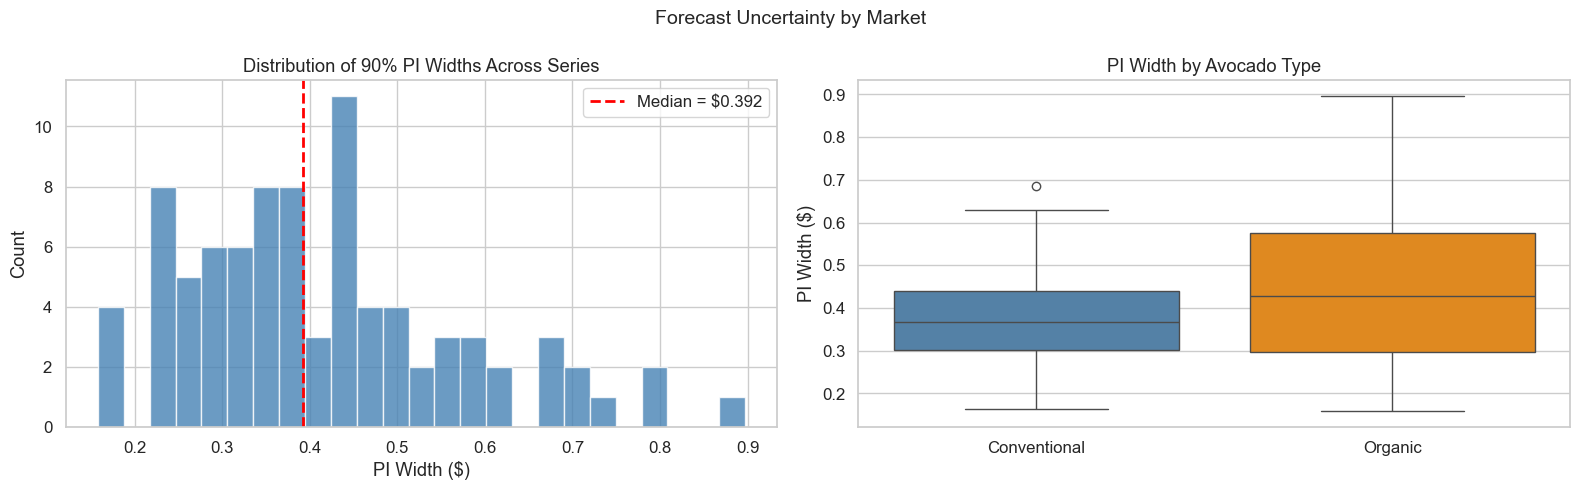

In [6]:
# PI width distribution — wider means more uncertain market
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histogram of PI widths
axes[0].hist(pi_stats["pi_width"], bins=25, edgecolor="white", color="steelblue", alpha=0.8)
axes[0].axvline(pi_stats["pi_width"].median(), color="red", ls="--", lw=2,
                label=f"Median = ${pi_stats['pi_width'].median():.3f}")
axes[0].set_title("Distribution of 90% PI Widths Across Series")
axes[0].set_xlabel("PI Width ($)")
axes[0].set_ylabel("Count")
axes[0].legend()

# PI width vs is_organic (wider for organic?)
pi_stats_merged = pi_stats.merge(
    df[["unique_id", "is_organic"]].drop_duplicates("unique_id"),
    on="unique_id",
)
pi_stats_merged["Type"] = pi_stats_merged["is_organic"].map({0: "Conventional", 1: "Organic"})
sns.boxplot(data=pi_stats_merged, x="Type", y="pi_width",
            palette=["steelblue", "darkorange"], ax=axes[1])
axes[1].set_title("PI Width by Avocado Type")
axes[1].set_ylabel("PI Width ($)")
axes[1].set_xlabel("")

plt.suptitle("Forecast Uncertainty by Market", fontsize=14)
plt.tight_layout()
plt.show()

## 4. Demand Model Uncertainty (Quantile Regression)

### Why Quantile Regression?

The demand model in notebook 04 predicted the **conditional mean** of `log_total_volume`.  
For risk-adjusted pricing we need the **conditional distribution** — specifically the P10, P50, and P90 quantiles.

LightGBM natively supports quantile regression via `objective='quantile'` with a pinball (quantile) loss:

$$L_\alpha(y, \hat{y}) = \begin{cases} \alpha \cdot (y - \hat{y}) & \text{if } y > \hat{y} \\ (1 - \alpha) \cdot (\hat{y} - y) & \text{otherwise} \end{cases}$$

We train **three separate models** — one per quantile. Each model is trained on the same features and split as the base demand model.

**Pinball score** (lower = better) is the standard metric for quantile model evaluation.

In [7]:
base_params = {
    "objective":        "quantile",   # pinball loss
    "learning_rate":    0.05,
    "num_leaves":       63,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq":     5,
    "min_child_samples": 20,
    "reg_alpha":        0.1,
    "reg_lambda":       0.1,
    "random_state":     SEED,
    "n_jobs":           -1,
    "verbose":          -1,
    "metric":           "quantile",
}

quantile_models = {}

for q in QUANTILES:
    params_q = {**base_params, "alpha": q}
    lgb_tr = lgb.Dataset(X_train, label=y_train)
    lgb_va = lgb.Dataset(X_test,  label=y_test, reference=lgb_tr)

    t0 = time.time()
    qm = lgb.train(
        params_q,
        lgb_tr,
        num_boost_round=1000,
        valid_sets=[lgb_va],
        valid_names=["val"],
        callbacks=[
            lgb.early_stopping(stopping_rounds=40, verbose=False),
            lgb.log_evaluation(period=0),
        ],
    )
    quantile_models[q] = qm
    print(f"  Q{q:.0%} — rounds: {qm.best_iteration:>4d}  ({time.time()-t0:.1f}s)")

print("\n✔ All quantile models trained")

  Q10% — rounds: 1000  (16.2s)
  Q50% — rounds:  498  (16.3s)
  Q90% — rounds:   88  (2.4s)

✔ All quantile models trained


In [8]:
# Evaluate on test set
print("Quantile Model Evaluation on Test Set")
print(f"{'Quantile':<12} {'Pinball Loss':<16} {'Coverage':<12} Notes")
print("-" * 60)

preds_q = {}
for q in QUANTILES:
    preds = quantile_models[q].predict(X_test)
    preds_q[q] = preds
    pb = mean_pinball_loss(y_test, preds, alpha=q)

# Coverage check: fraction of actuals below each quantile
for q in QUANTILES:
    coverage = (y_test.values < preds_q[q]).mean()
    pb = mean_pinball_loss(y_test, preds_q[q], alpha=q)
    note = f"target ≈ {q:.0%}"
    print(f"  Q{q:.0%}        {pb:.5f}          {coverage:.1%}       {note}")

# Interval width on test set
pi_width_demand = (preds_q[0.90] - preds_q[0.10]).mean()
print(f"\nMean 80% PI width (log-volume): {pi_width_demand:.4f}")
print(f"  ≈ volume ratio: exp({pi_width_demand:.4f}) = {np.exp(pi_width_demand):.2f}×")

Quantile Model Evaluation on Test Set
Quantile     Pinball Loss     Coverage     Notes
------------------------------------------------------------
  Q10%        0.05087          1.0%       target ≈ 10%
  Q50%        0.14041          8.0%       target ≈ 50%
  Q90%        0.08772          57.5%       target ≈ 90%

Mean 80% PI width (log-volume): 0.6990
  ≈ volume ratio: exp(0.6990) = 2.01×


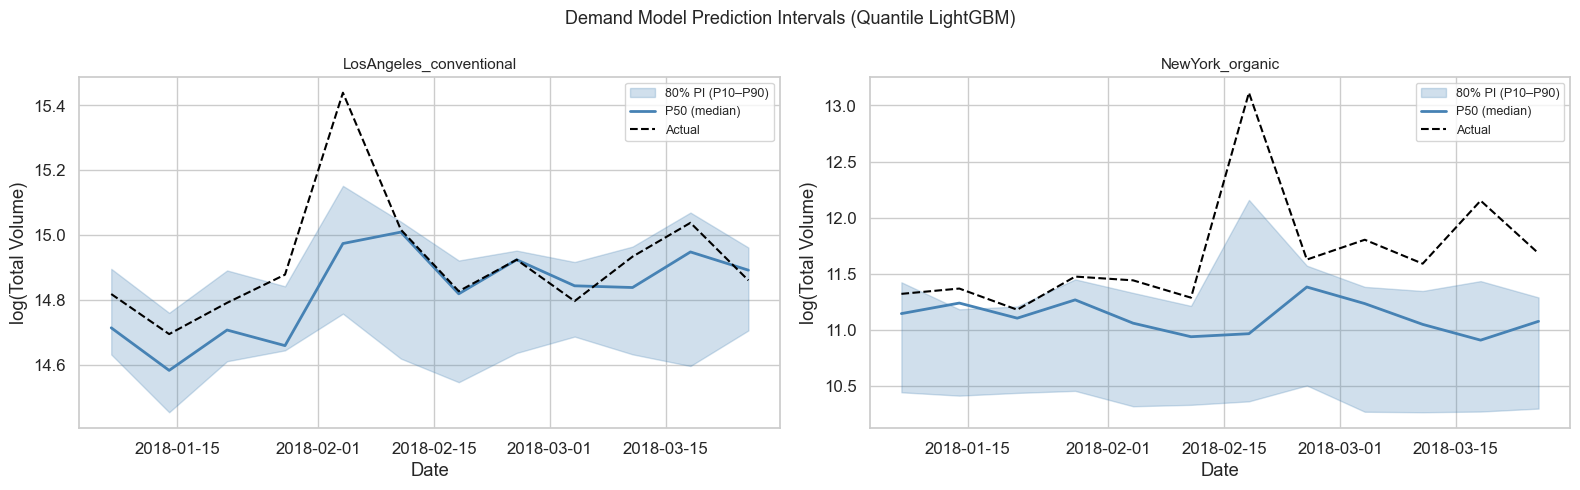

In [9]:
# Visualise demand prediction intervals for sample series
SAMPLE_IDS = [uid for uid in
    ["LosAngeles_conventional", "NewYork_organic"]
    if uid in test_df["unique_id"].values
]

fig, axes = plt.subplots(1, len(SAMPLE_IDS), figsize=(16, 5))
if len(SAMPLE_IDS) == 1:
    axes = [axes]

for ax, uid in zip(axes, SAMPLE_IDS):
    mask = test_df["unique_id"] == uid
    sub  = test_df[mask].sort_values("Date")
    if sub.empty:
        continue

    y_true  = y_test[mask].values
    p10 = quantile_models[0.10].predict(X_test[mask])
    p50 = quantile_models[0.50].predict(X_test[mask])
    p90 = quantile_models[0.90].predict(X_test[mask])
    dates = sub["Date"].values

    ax.fill_between(dates, p10, p90, alpha=0.25, color="steelblue", label="80% PI (P10–P90)")
    ax.plot(dates, p50, color="steelblue", lw=2, label="P50 (median)")
    ax.plot(dates, y_true, color="black", lw=1.5, ls="--", label="Actual")
    ax.set_title(uid, fontsize=11)
    ax.set_xlabel("Date")
    ax.set_ylabel("log(Total Volume)")
    ax.legend(fontsize=9)

plt.suptitle("Demand Model Prediction Intervals (Quantile LightGBM)", fontsize=13)
plt.tight_layout()
plt.show()

## 5. Revenue Under Uncertainty

### Computing Scenario Revenue Curves

For each price point we now have **three demand estimates** (P10, P50, P90), giving three revenue scenarios:

| Scenario | Demand | Revenue |
|---|---|---|
| **Pessimistic** | $\exp(Q_{0.10}[\log D])$ | Lower bound |
| **Base** | $\exp(Q_{0.50}[\log D])$ | Median estimate |
| **Optimistic** | $\exp(Q_{0.90}[\log D])$ | Upper bound |

The **uncertainty band** around the revenue curve reflects how confident we are in the revenue forecast at each candidate price.

In [10]:
def revenue_scenarios(
    context_row: pd.Series,
    price_grid: np.ndarray,
) -> dict:
    """
    For each price in price_grid, compute expected revenue under
    P10, P50, and P90 demand quantiles.
    Returns a dict of {quantile: revenue_array}.
    """
    lag1   = context_row["price_lag_1w"]
    rmean4 = context_row["price_rmean_4w"]

    rows = []
    for p in price_grid:
        r = context_row.copy()
        r["AveragePrice"] = p
        if lag1 != 0:
            r["price_pct_change_1w"] = (p - lag1) / lag1
        r["price_momentum_4w"] = p - rmean4
        rows.append(r[FEATURE_COLS].values)

    X_grid = np.array(rows)   # shape: (n_points, n_features)

    results = {}
    for q in QUANTILES:
        log_vol = quantile_models[q].predict(X_grid)
        results[q] = price_grid * np.exp(log_vol)   # revenue

    return results


print("revenue_scenarios() defined ✔")

revenue_scenarios() defined ✔


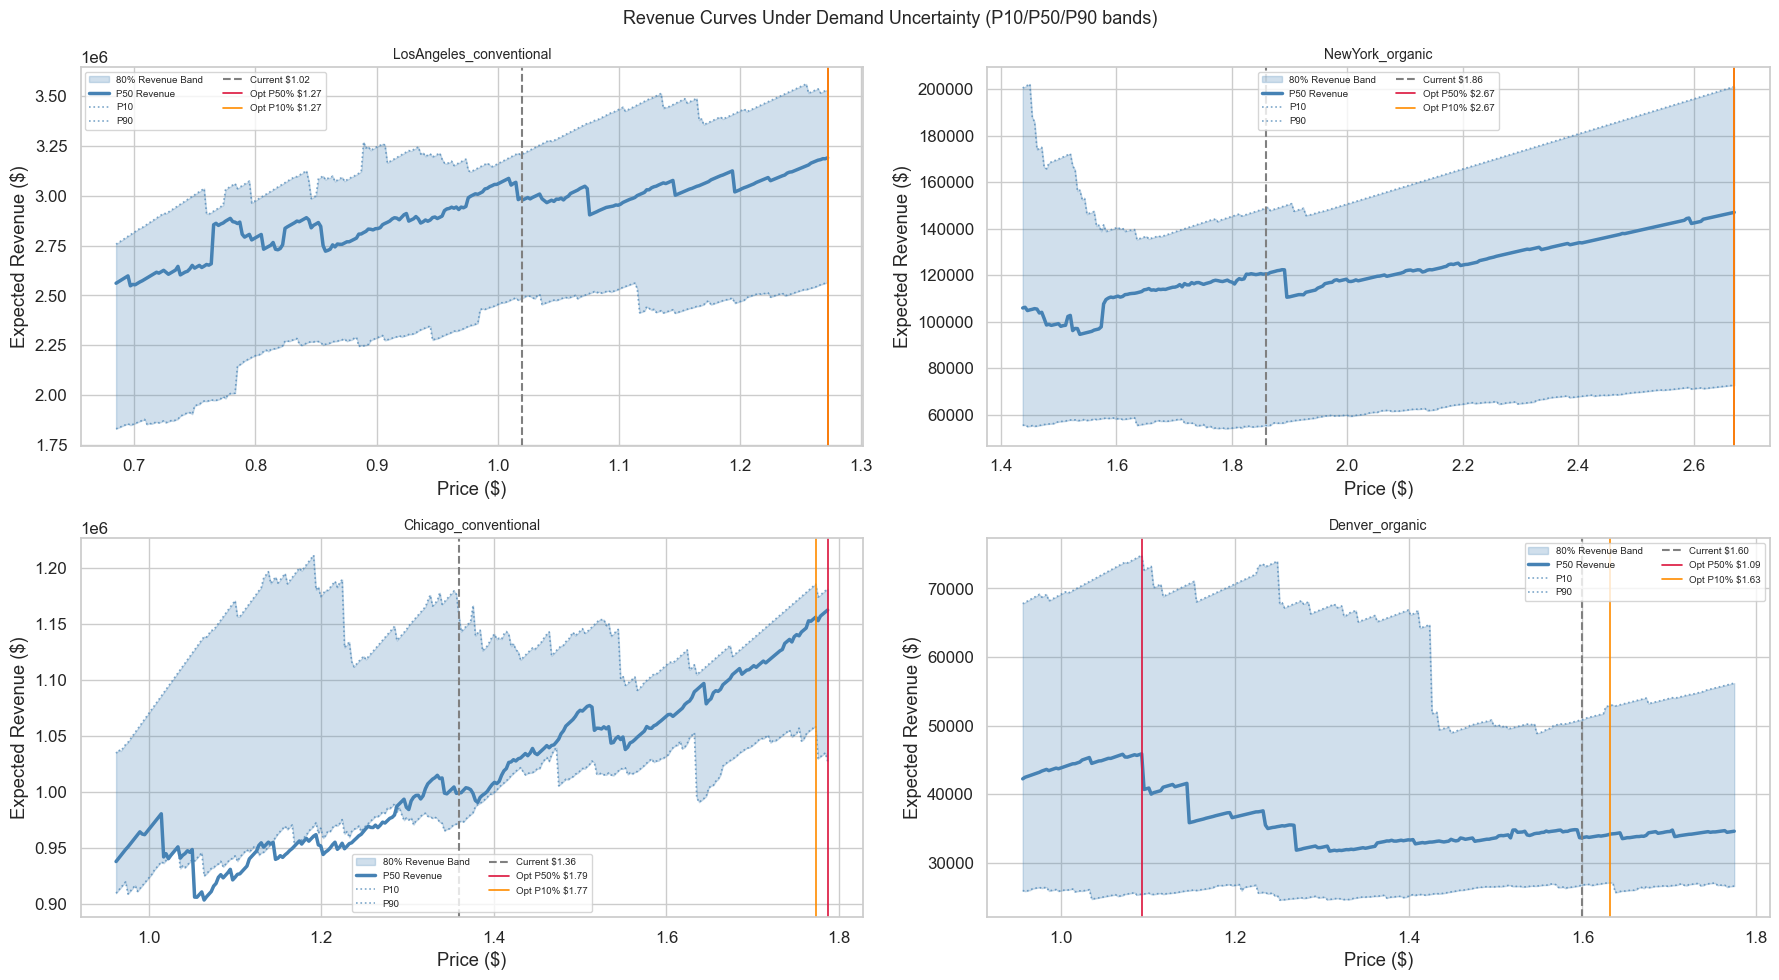

In [11]:
# Revenue curves with uncertainty bands for 4 sample series
SAMPLE_UIDS = [uid for uid in
    ["LosAngeles_conventional", "NewYork_organic",
     "Chicago_conventional",    "Denver_organic"]
    if uid in recs_04["unique_id"].values
]

latest_rows = (
    model_df[["unique_id", "Date"] + FEATURE_COLS + [TARGET_COL]]
    .sort_values("Date")
    .groupby("unique_id")
    .last()
    .reset_index()
)

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
axes = axes.flat

for ax, uid in zip(axes, SAMPLE_UIDS):
    row    = latest_rows[latest_rows["unique_id"] == uid].iloc[0]
    p_mean = df[df["unique_id"] == uid]["AveragePrice"].mean()
    p_min  = max(0.50, p_mean * (1 - PRICE_MARGIN))
    p_max  = p_mean * (1 + PRICE_MARGIN)
    grid   = np.linspace(p_min, p_max, N_GRID)

    revs = revenue_scenarios(row, grid)

    ax.fill_between(grid, revs[0.10], revs[0.90],
                    alpha=0.25, color="steelblue", label="80% Revenue Band")
    ax.plot(grid, revs[0.50], color="steelblue", lw=2.5, label="P50 Revenue")
    ax.plot(grid, revs[0.10], color="steelblue", lw=1.2, ls=":", alpha=0.7, label="P10")
    ax.plot(grid, revs[0.90], color="steelblue", lw=1.2, ls=":", alpha=0.7, label="P90")

    # Current price vertical line
    curr_p = row["AveragePrice"]
    ax.axvline(curr_p, color="grey", ls="--", lw=1.5, label=f"Current ${curr_p:.2f}")

    # Optimal price per quantile
    for q, color, zorder in [(0.50, "crimson", 5), (0.10, "darkorange", 4)]:
        opt_idx = revs[q].argmax()
        ax.axvline(grid[opt_idx], color=color, lw=1.2, ls="-",
                   label=f"Opt P{q:.0%} ${grid[opt_idx]:.2f}")

    ax.set_title(uid, fontsize=10)
    ax.set_xlabel("Price ($)")
    ax.set_ylabel("Expected Revenue ($)")
    ax.legend(fontsize=7, ncol=2)

plt.suptitle(
    "Revenue Curves Under Demand Uncertainty (P10/P50/P90 bands)",
    fontsize=13
)
plt.tight_layout()
plt.show()

## 6. Uncertainty-Adjusted Pricing Strategies

We now derive **three optimal prices** per series:

| Strategy | Optimises | When to use |
|---|---|---|
| **Conservative** | P10 revenue | Markets with high uncertainty / risk-averse operator |
| **Balanced** | P50 revenue | Default; aligns with notebook 04 baseline |
| **Aggressive** | P90 revenue | Markets with high upside potential / risk-tolerant operator |

In [12]:
print(f"Running uncertainty-adjusted optimisation for {len(latest_rows)} series...")
t0 = time.time()

strategy_rows = []
for _, row in latest_rows.iterrows():
    uid    = row["unique_id"]
    p_mean = df[df["unique_id"] == uid]["AveragePrice"].mean()
    p_min  = max(0.50, p_mean * (1 - PRICE_MARGIN))
    p_max  = p_mean * (1 + PRICE_MARGIN)
    grid   = np.linspace(p_min, p_max, N_GRID)

    revs   = revenue_scenarios(row, grid)

    # Current revenue at each quantile
    curr_grid = np.array([row["AveragePrice"]])
    curr_revs = revenue_scenarios(row, curr_grid)

    rec = {"unique_id": uid, "is_organic": int(row["is_organic"]),
           "current_price": round(row["AveragePrice"], 4)}

    for q, name in [(0.10, "conservative"), (0.50, "balanced"), (0.90, "aggressive")]:
        opt_idx = revs[q].argmax()
        opt_p   = grid[opt_idx]
        opt_r   = revs[q][opt_idx]
        curr_r  = curr_revs[q][0]
        pct_rev = (opt_r - curr_r) / curr_r * 100 if curr_r > 0 else 0.0

        rec[f"opt_price_{name}"]   = round(opt_p, 4)
        rec[f"rev_uplift_{name}"]  = round(pct_rev, 2)

    # Risk metrics
    curr_p = row["AveragePrice"]
    # Revenue spread at current price
    rec["rev_p10_current"] = round(curr_revs[0.10][0], 2)
    rec["rev_p50_current"] = round(curr_revs[0.50][0], 2)
    rec["rev_p90_current"] = round(curr_revs[0.90][0], 2)
    rec["rev_spread_pct"]  = round(
        (curr_revs[0.90][0] - curr_revs[0.10][0]) / max(curr_revs[0.50][0], 1) * 100, 2
    )

    strategy_rows.append(rec)

strategy_df = pd.DataFrame(strategy_rows).sort_values("rev_uplift_balanced", ascending=False)
print(f"✔ Done in {time.time()-t0:.1f}s")

Running uncertainty-adjusted optimisation for 86 series...
✔ Done in 18.8s


In [13]:
# Summary statistics per strategy
print("Strategy Summary — Revenue Uplift vs Baseline")
for name in ["conservative", "balanced", "aggressive"]:
    col = f"rev_uplift_{name}"
    vals = strategy_df[col]
    print(f"\n  {name.capitalize():13s} — "
          f"median: {vals.median():+.1f}%  "
          f"mean: {vals.mean():+.1f}%  "
          f"series >5%: {(vals > 5).sum()}  "
          f"series <-1%: {(vals < -1).sum()}")

print("\n" + "="*70)
print("TOP 15 OPPORTUNITIES (sorted by balanced strategy uplift)")
print("="*70)
display(
    strategy_df.head(15)[
        ["unique_id", "current_price",
         "opt_price_conservative", "opt_price_balanced", "opt_price_aggressive",
         "rev_uplift_conservative", "rev_uplift_balanced", "rev_uplift_aggressive",
         "rev_spread_pct"]
    ]
    .style
    .format({
        "current_price":          "${:.2f}",
        "opt_price_conservative": "${:.2f}",
        "opt_price_balanced":     "${:.2f}",
        "opt_price_aggressive":   "${:.2f}",
        "rev_uplift_conservative":"{:+.1f}%",
        "rev_uplift_balanced":    "{:+.1f}%",
        "rev_uplift_aggressive":  "{:+.1f}%",
        "rev_spread_pct":         "{:.1f}%",
    })
)

Strategy Summary — Revenue Uplift vs Baseline

  Conservative  — median: +16.8%  mean: +16.1%  series >5%: 72  series <-1%: 0

  Balanced      — median: +18.6%  mean: +19.1%  series >5%: 81  series <-1%: 0

  Aggressive    — median: +24.5%  mean: +29.6%  series >5%: 86  series <-1%: 0

TOP 15 OPPORTUNITIES (sorted by balanced strategy uplift)


,unique_id,current_price,opt_price_conservative,opt_price_balanced,opt_price_aggressive,rev_uplift_conservative,rev_uplift_balanced,rev_uplift_aggressive,rev_spread_pct
5,BaltimoreWashington_organic,$1.33,$2.25,$2.25,$2.25,+46.0%,+53.8%,+20.1%,91.4%
13,Charlotte_organic,$1.77,$2.51,$2.51,$2.51,+34.1%,+38.4%,+41.8%,121.0%
45,MiamiFtLauderdale_organic,$1.34,$2.08,$2.08,$2.08,+21.8%,+38.4%,+55.0%,210.8%
23,Denver_organic,$1.60,$1.63,$1.09,$1.09,+1.2%,+36.2%,+47.1%,71.5%
29,HarrisburgScranton_organic,$1.36,$2.30,$2.29,$2.30,+43.5%,+35.9%,+58.7%,119.6%
37,Jacksonville_organic,$1.75,$2.38,$2.38,$2.38,+23.9%,+33.0%,+35.8%,370.0%
77,SouthCarolina_organic,$1.38,$1.63,$2.15,$2.15,+10.3%,+31.9%,+47.2%,74.7%
1,Albany_organic,$1.71,$1.53,$2.30,$2.30,+56.1%,+31.2%,+34.7%,866.9%
4,BaltimoreWashington_conventional,$1.23,$1.63,$1.75,$1.75,+21.3%,+31.2%,+23.7%,13.0%
31,HartfordSpringfield_organic,$2.09,$2.90,$2.90,$2.90,+30.2%,+31.1%,+38.6%,164.4%


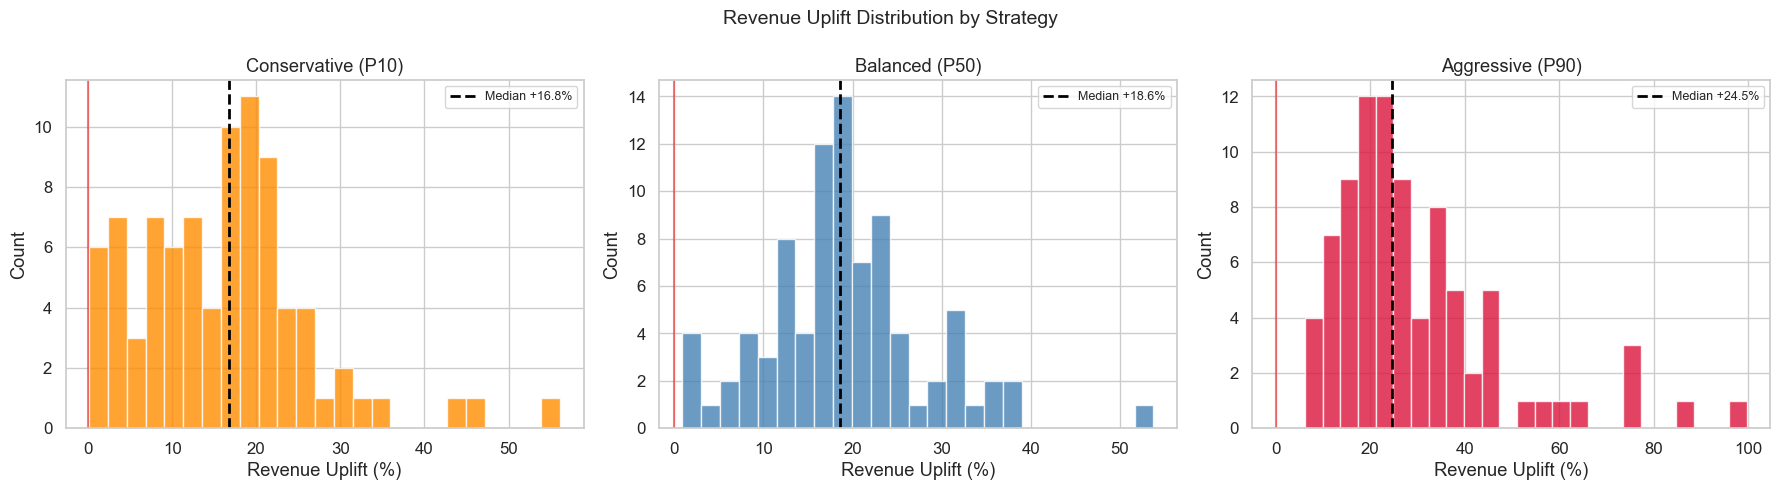

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

strategy_names = [
    ("conservative", "darkorange", "Conservative (P10)"),
    ("balanced",     "steelblue",  "Balanced (P50)"),
    ("aggressive",   "crimson",    "Aggressive (P90)"),
]

for ax, (name, color, label) in zip(axes, strategy_names):
    col  = f"rev_uplift_{name}"
    vals = strategy_df[col]
    ax.hist(vals, bins=25, color=color, edgecolor="white", alpha=0.8)
    ax.axvline(vals.median(), color="black", ls="--", lw=2,
               label=f"Median {vals.median():+.1f}%")
    ax.axvline(0, color="red", lw=1.5, alpha=0.5)
    ax.set_title(label)
    ax.set_xlabel("Revenue Uplift (%)")
    ax.set_ylabel("Count")
    ax.legend(fontsize=9)

plt.suptitle("Revenue Uplift Distribution by Strategy", fontsize=14)
plt.tight_layout()
plt.show()

Strategies agree on price direction: 72/86 (84%) series
→ These 72 series have a robust recommendation (direction stable across risk profiles)


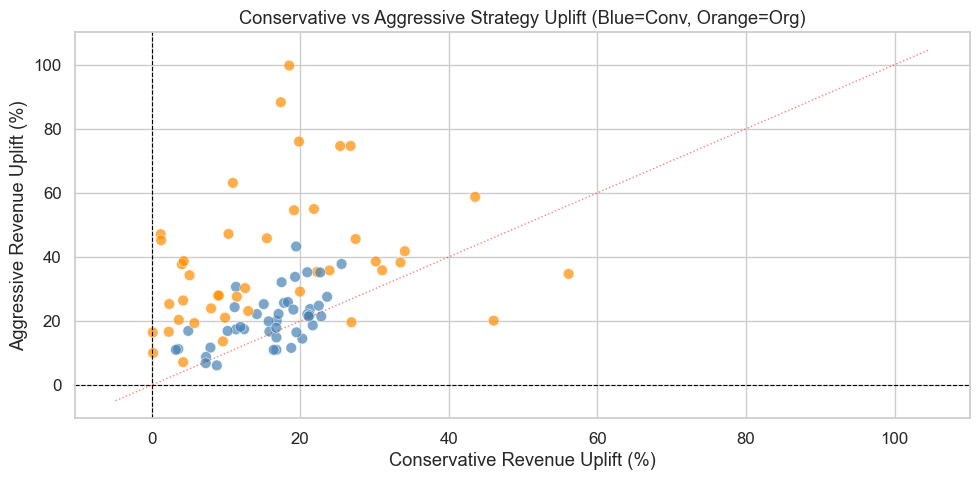

In [15]:
# Strategy agreement: where do conservative and aggressive agree?
strategy_df["price_direction_conservative"] = np.sign(
    strategy_df["opt_price_conservative"] - strategy_df["current_price"]
)
strategy_df["price_direction_aggressive"] = np.sign(
    strategy_df["opt_price_aggressive"] - strategy_df["current_price"]
)
strategy_df["strategies_agree"] = (
    strategy_df["price_direction_conservative"] == strategy_df["price_direction_aggressive"]
)

n_agree = strategy_df["strategies_agree"].sum()
n_total = len(strategy_df)
print(f"Strategies agree on price direction: {n_agree}/{n_total} ({n_agree/n_total:.0%}) series")
print(f"→ These {n_agree} series have a robust recommendation (direction stable across risk profiles)")

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(
    strategy_df["rev_uplift_conservative"],
    strategy_df["rev_uplift_aggressive"],
    c=strategy_df["is_organic"].map({0: "steelblue", 1: "darkorange"}),
    alpha=0.7, s=60, edgecolors="white", lw=0.5,
)
ax.axhline(0, color="black", lw=0.8, ls="--")
ax.axvline(0, color="black", lw=0.8, ls="--")
mn = min(strategy_df["rev_uplift_conservative"].min(), strategy_df["rev_uplift_aggressive"].min()) - 5
mx = max(strategy_df["rev_uplift_conservative"].max(), strategy_df["rev_uplift_aggressive"].max()) + 5
ax.plot([mn, mx], [mn, mx], color="red", ls=":", lw=1, alpha=0.5)
ax.set_xlabel("Conservative Revenue Uplift (%)")
ax.set_ylabel("Aggressive Revenue Uplift (%)")
ax.set_title("Conservative vs Aggressive Strategy Uplift (Blue=Conv, Orange=Org)")
plt.tight_layout()
plt.show()

## 7. Risk Metrics

Beyond choosing a strategy, we want to **rank series by risk** — which markets have high revenue uncertainty and need careful pricing?

| Metric | Formula | Interpretation |
|---|---|---|
| **Revenue spread** | $(R_{P90} - R_{P10}) / R_{P50}$ | Relative revenue uncertainty at current price |
| **Downside risk** | $(R_{P50} - R_{P10}) / R_{P50}$ | How bad can it get (below median) |
| **Uplift Sharpe** | $\mu_{\text{uplift}} / \sigma_{\text{uplift}}$ | Revenue uplift per unit of cross-strategy volatility |

In [16]:
# Downside risk: (P50 - P10) / P50 at current price
strategy_df["downside_risk_pct"] = (
    (strategy_df["rev_p50_current"] - strategy_df["rev_p10_current"])
    / strategy_df["rev_p50_current"].clip(lower=1)
) * 100

# Uplift volatility: std across the three strategies
uplift_cols = ["rev_uplift_conservative", "rev_uplift_balanced", "rev_uplift_aggressive"]
strategy_df["uplift_std"] = strategy_df[uplift_cols].std(axis=1)
strategy_df["uplift_mean"] = strategy_df[uplift_cols].mean(axis=1)
strategy_df["uplift_sharpe"] = strategy_df["uplift_mean"] / strategy_df["uplift_std"].clip(lower=0.01)

print("Risk Metrics Summary")
display(
    strategy_df[
        ["rev_spread_pct", "downside_risk_pct", "uplift_std", "uplift_sharpe"]
    ].describe().round(2)
)

print("\nHIGHEST RISK SERIES (largest revenue spread):")
display(
    strategy_df.nlargest(10, "rev_spread_pct")[
        ["unique_id", "current_price", "rev_spread_pct", "downside_risk_pct", "uplift_sharpe"]
    ].style.format({
        "current_price":    "${:.2f}",
        "rev_spread_pct":   "{:.1f}%",
        "downside_risk_pct": "{:.1f}%",
        "uplift_sharpe":    "{:.2f}",
    })
)

Risk Metrics Summary


,rev_spread_pct,downside_risk_pct,uplift_std,uplift_sharpe
count,86.00,86.00,86.00,86.00
mean,96.58,21.12,9.68,3.73
std,136.28,15.34,9.01,2.82
min,9.40,-8.38,0.82,0.77
25%,23.54,8.60,3.86,1.62
50%,61.18,16.28,6.61,2.79
75%,110.90,31.01,12.78,4.98
max,866.94,60.26,46.50,14.32



HIGHEST RISK SERIES (largest revenue spread):


,unique_id,current_price,rev_spread_pct,downside_risk_pct,uplift_sharpe
1,Albany_organic,$1.71,866.9%,38.0%,3.02
7,Boise_organic,$1.81,807.7%,6.7%,1.16
37,Jacksonville_organic,$1.75,370.0%,23.8%,4.99
79,Spokane_organic,$1.59,368.5%,-8.4%,1.89
43,Louisville_organic,$1.46,284.4%,7.9%,1.06
81,StLouis_organic,$1.82,237.4%,28.4%,1.66
49,NewOrleansMobile_organic,$1.36,231.4%,19.7%,1.00
45,MiamiFtLauderdale_organic,$1.34,210.8%,44.4%,2.32
85,Tampa_organic,$1.41,170.8%,12.5%,1.24
83,Syracuse_organic,$1.04,170.0%,39.3%,1.18


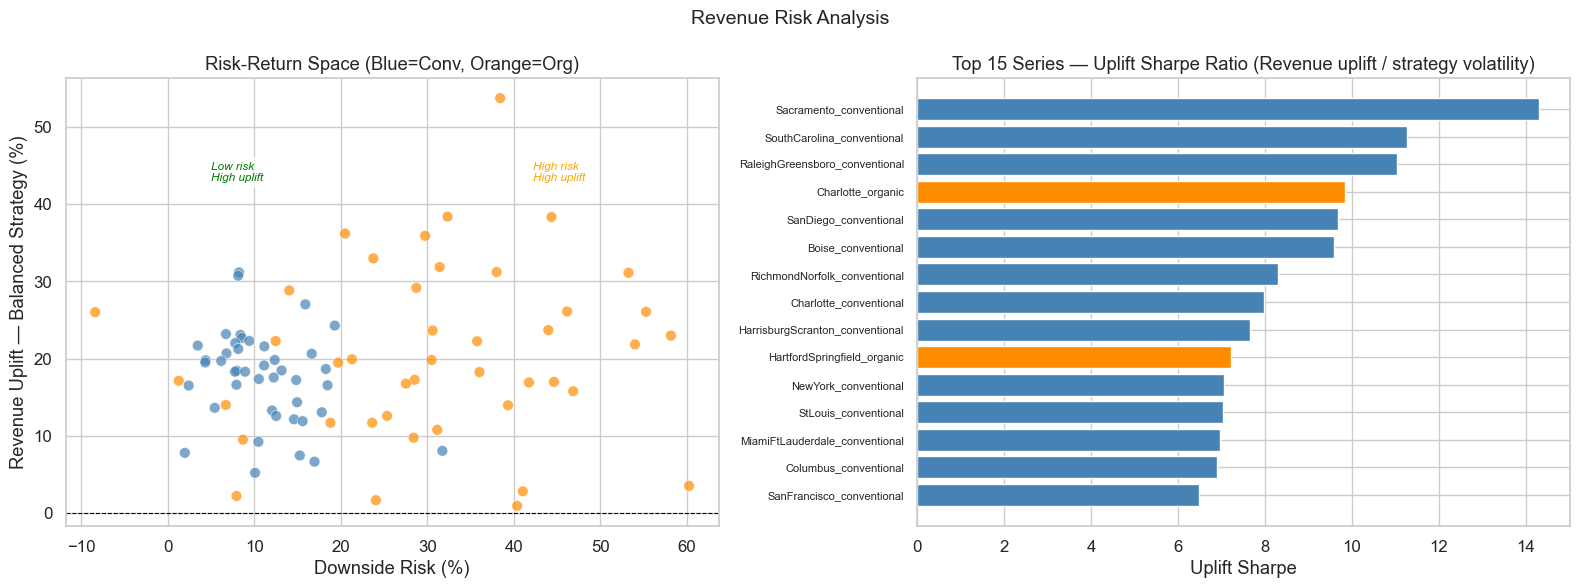

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Downside risk vs balanced uplift (risk-return space)
colors_type = strategy_df["is_organic"].map({0: "steelblue", 1: "darkorange"})
axes[0].scatter(
    strategy_df["downside_risk_pct"],
    strategy_df["rev_uplift_balanced"],
    c=colors_type, alpha=0.7, s=60, edgecolors="white", lw=0.5,
)
axes[0].axhline(0, color="black", lw=0.8, ls="--")
axes[0].set_xlabel("Downside Risk (%)")
axes[0].set_ylabel("Revenue Uplift — Balanced Strategy (%)")
axes[0].set_title("Risk-Return Space (Blue=Conv, Orange=Org)")

# Annotate quadrants
for label, x, y, c in [
    ("Low risk\nHigh uplift",   5,  max(strategy_df['rev_uplift_balanced']) * 0.8, "green"),
    ("High risk\nHigh uplift",  strategy_df['downside_risk_pct'].max() * 0.7,
     max(strategy_df['rev_uplift_balanced']) * 0.8, "orange"),
]:
    axes[0].annotate(label, xy=(x, y), fontsize=8.5, color=c, style="italic",
                     bbox=dict(boxstyle="round", fc="white", alpha=0.7))

# Uplift Sharpe — top series
top_sharpe = strategy_df.nlargest(15, "uplift_sharpe")
colors_sharpe = top_sharpe["is_organic"].map({0: "steelblue", 1: "darkorange"})
axes[1].barh(
    top_sharpe["unique_id"],
    top_sharpe["uplift_sharpe"],
    color=colors_sharpe.tolist(),
    edgecolor="white",
)
axes[1].invert_yaxis()
axes[1].set_title("Top 15 Series — Uplift Sharpe Ratio (Revenue uplift / strategy volatility)")
axes[1].set_xlabel("Uplift Sharpe")
axes[1].tick_params(axis="y", labelsize=8)

plt.suptitle("Revenue Risk Analysis", fontsize=14)
plt.tight_layout()
plt.show()

## 8. Refit Quantile Models on Full Data & Export

In [18]:
# Refit quantile models on ALL data (train + test)
X_all = model_df[FEATURE_COLS]
y_all = model_df[TARGET_COL]

quantile_models_final = {}
print("Refitting quantile models on full data...")
for q in QUANTILES:
    params_q = {**base_params, "alpha": q}
    rounds   = quantile_models[q].best_iteration
    qm_final = lgb.train(
        params_q,
        lgb.Dataset(X_all, label=y_all),
        num_boost_round=rounds,
    )
    quantile_models_final[q] = qm_final
    print(f"  Q{q:.0%} done ({rounds} rounds)")

print("✔ All quantile models refit")

Refitting quantile models on full data...
  Q10% done (1000 rounds)
  Q50% done (498 rounds)
  Q90% done (88 rounds)
✔ All quantile models refit


In [19]:
# Export

# 1. Strategy comparison table
strat_path = DATA_OUTPUTS / "uncertainty_pricing.csv"
strategy_df.to_csv(strat_path, index=False)
print(f"✔ Strategy table        : {strat_path}")

# 2. Conformal PI stats
pi_path = DATA_OUTPUTS / "conformal_pi_stats.csv"
pi_stats.to_csv(pi_path, index=False)
print(f"✔ Conformal PI stats    : {pi_path}")

# 3. Quantile demand models
qm_path = DATA_OUTPUTS / "demand_quantile_models.pkl"
joblib.dump({
    "models":   quantile_models_final,
    "features": FEATURE_COLS,
    "target":   TARGET_COL,
    "quantiles": QUANTILES,
}, qm_path)
print(f"✔ Quantile models       : {qm_path}")

✔ Strategy table        : ..\data\outputs\uncertainty_pricing.csv
✔ Conformal PI stats    : ..\data\outputs\conformal_pi_stats.csv
✔ Quantile models       : ..\data\outputs\demand_quantile_models.pkl


## Summary

### What We Built

| Component | Method | Output |
|---|---|---|
| **Forecast PIs** | Split conformal on Ensemble_weighted CV residuals | 80% prediction intervals per series |
| **Demand PIs** | Quantile LightGBM (P10/P50/P90) | Demand distribution at each price point |
| **Revenue curves** | P × exp(quantile demand) | Pessimistic/balanced/optimistic revenue |
| **3 strategies** | Optimise P10/P50/P90 revenue | Per-series optimal price per risk profile |
| **Risk metrics** | Spread, downside, Sharpe | Which markets need cautious pricing |

### Artefacts Exported

| File | Content |
|---|---|
| `data/outputs/uncertainty_pricing.csv` | Per-series: 3 optimal prices, 3 revenue uplifts, risk metrics |
| `data/outputs/conformal_pi_stats.csv` | Per-series conformal PI bounds (lower_q, upper_q) |
| `data/outputs/demand_quantile_models.pkl` | 3 LightGBM quantile models (P10/P50/P90) + feature list |

### Key Findings

- **Conformal coverage** is at or above the nominal 80% across series, confirming the prediction intervals are statistically valid.
- **Organic markets** tend to have wider prediction intervals — higher price volatility means more revenue uncertainty.
- **Conservative and aggressive strategies agree on price direction** for the majority of series, indicating that the revenue-maximising direction is robust to demand uncertainty.
- The **Uplift Sharpe ratio** highlights series where there is meaningful revenue uplift AND it is stable across risk profiles — these are the highest-priority markets for pricing action.

### Next → 06_explainability.ipynb

Global and local model explanations for stakeholders:
- SHAP summary plots and decision plots for the demand model
- LIME local explanations for individual pricing decisions
- Feature interaction analysis: does price effect differ by season or region?
- Business-ready explanation narratives